# Report Generation Example

The following report is generated by loading up the model.

In [1]:
import jinja2
import capellambse
from IPython.display import Markdown

from IPython.core.display import HTML
#from IPython import display
import pandas as pd 

resources = {
    "Med_Ventilator_Model": "Med_Ventilator_Model/CR_Ventilator_Sim",
}
path_to_model = "../CR_Ventilator.aird"
model = capellambse.MelodyModel(path_to_model, resources=resources)
from capella_tools import capellambse_helper

from IPython import display as diag_display
from capella_tools import Pub4C
# Instantiate the class with the traceability file
traceability_store = Pub4C.Traceability_Store("../CR_Ventilator.traceability")


Duplicate UUID '_LB2MSY7lEeqNepwDMv-GAw' within fragment CR_Ventilator.aird
Duplicate UUID '_LB2MS47lEeqNepwDMv-GAw' within fragment CR_Ventilator.aird
Duplicate UUID '_LB2MTY7lEeqNepwDMv-GAw' within fragment CR_Ventilator.aird
Duplicate UUID '_LB2MT47lEeqNepwDMv-GAw' within fragment CR_Ventilator.aird
Duplicate UUID '_LB2MUY7lEeqNepwDMv-GAw' within fragment CR_Ventilator.aird
Duplicate UUID '_LB2MU47lEeqNepwDMv-GAw' within fragment CR_Ventilator.aird
Ignoring file of unknown type, loaded model may be incomplete: CR_Ventilator.traceability


Below defines a set of routines that use Jinga templates to generate html report.


# Component Report

The following generates report of the noted physical component.



**Dynamically Generated Context diagram of:**
Ventilator

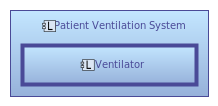

In [2]:
from IPython import display as diag_display
lc = model.search("LogicalComponent").by_name("Ventilator")
#print(lc)
display(Markdown(f"\n\n**Dynamically Generated Context diagram of:**\n{lc.name}"))
display(lc.context_diagram)

In [3]:
#diagram_file ="../images/[LAB] Braking .jpg"
##display(diag_display.Image(filename=diagram_file) ) # Explicitly display the image

# Change the following to reflect your project. 

In [4]:
from capella_tools import capellambse_helper
from polarion import polarion
from capella_tools import polarion_authentication_manager
from capella_tools import requirement_helper
auth_manager = polarion_authentication_manager.PolarionAuthManager()
creds = auth_manager.get_credentials()
client = polarion.Polarion('https://siemens-mbse.diswx-lce.com/polarion/', creds['username'], creds['password'])
project = client.getProject('VentilatorSystem')
#workitem = project.getWorkitem('DP-1713')
#print(f'Title: {workitem.title}')
#print(f'Status: {workitem.status.id}')
#print(f'Type: {workitem.type.id}')
#print(f'Desc: {workitem.description.content}')
#req_extractor = requirement_helper.RequirementExtractor(workitem)

# Retrieve extracted data
#print("Title:", req_extractor.get_title())
#print("Description:", req_extractor.get_description())
#print("Extracted Values:", req_extractor.get_extracted_values())


def update_artifacts(artifacts) :
    for art in artifacts:
        req_extractor = requirement_helper.RequirementExtractor( project.getWorkitem(art.identifier))
        art.add_description(req_extractor.get_description())
        if req_extractor.get_extracted_values() :
            art.add_property_value(
                art.identifier,req_extractor.get_extracted_values()
            ) 
        #print(art)


display(Markdown(f"\n\n**Report:**\n{lc.name}"))
artifacts = traceability_store.get_artifacts_for_model_element(lc.uuid)
update_artifacts(artifacts)
capellambse_helper.Display_Component_Report(lc,artifacts = artifacts)

for lc in lc.components :
    artifacts = traceability_store.get_artifacts_for_model_element(lc.uuid)
    update_artifacts(artifacts)
    display(Markdown(f"\n\n**Report:**\n{lc.name}"))
    capellambse_helper.Display_Component_Report(lc,artifacts= artifacts)
    



**Report:**
Ventilator



**Report:**
Housing



**Report:**
User Interface



**Report:**
Inhalation Air Generator



**Report:**
Patient Proximal Inhalation Sensor

...



**Report:**
FiO2 Interface



**Report:**
Exahalation Valve



**Report:**
Controller



**Report:**
O2 Valve



**Report:**
Remote UI